First 5 rows:
       name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

Shape: (15, 9)

Data Types:
 name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

Summary:
             math    science    english    history 

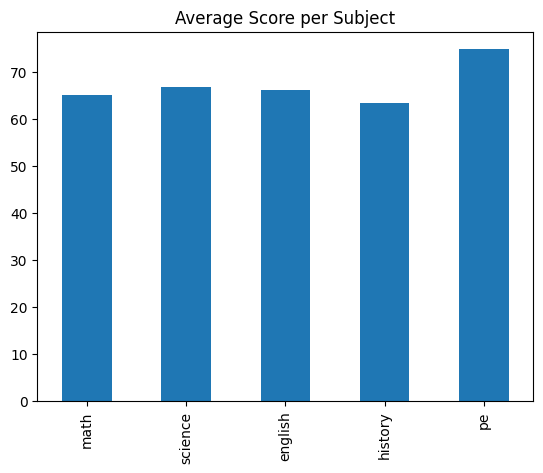

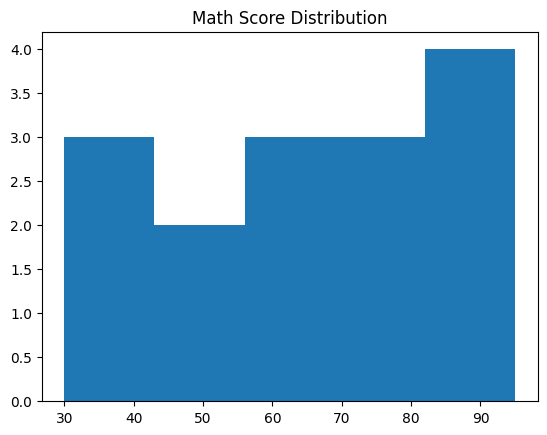

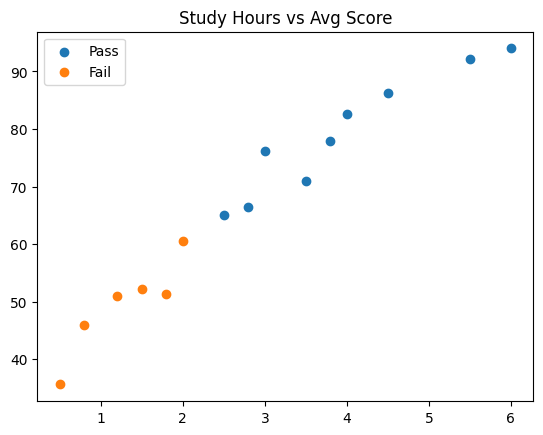

/tmp/ipykernel_3400/2434606127.py:86: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_df["attendance_pct"], fail_df["attendance_pct"]], labels=["Pass", "Fail"])


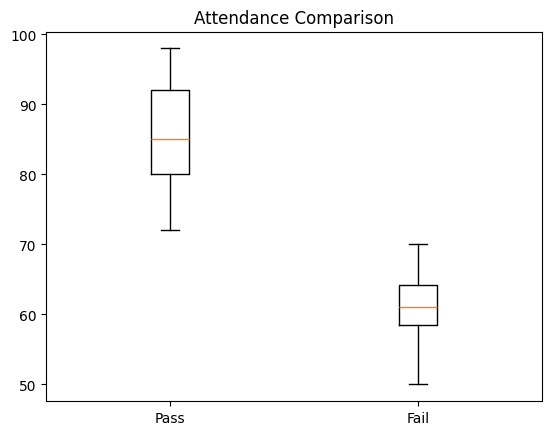

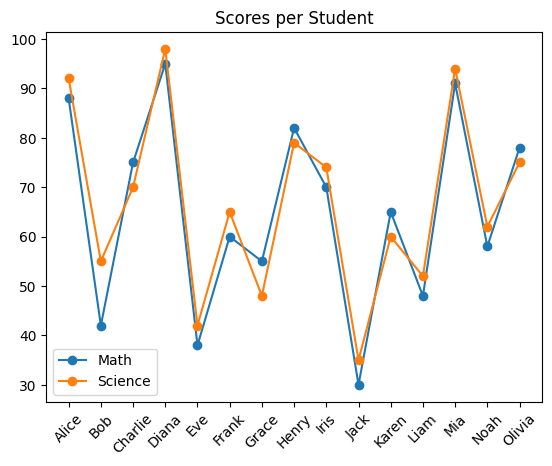

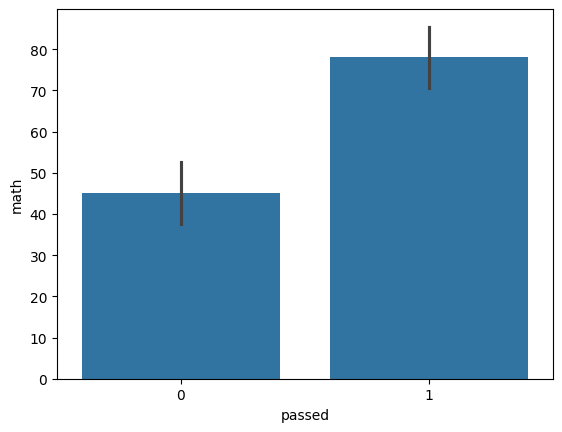

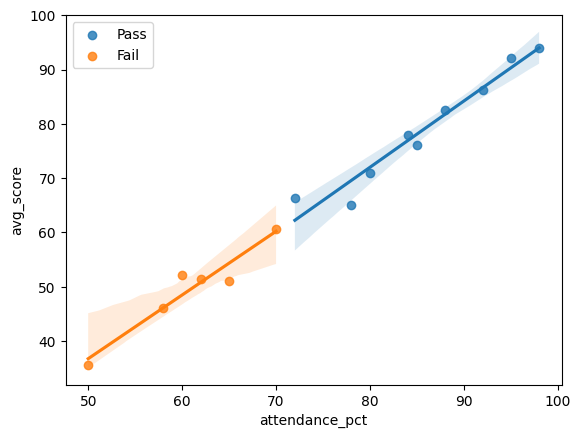


Training Accuracy: 1.0
Test Accuracy: 1.0
Jack | Actual: 0 | Pred: 0
Liam | Actual: 0 | Pred: 0
Alice | Actual: 1 | Pred: 1


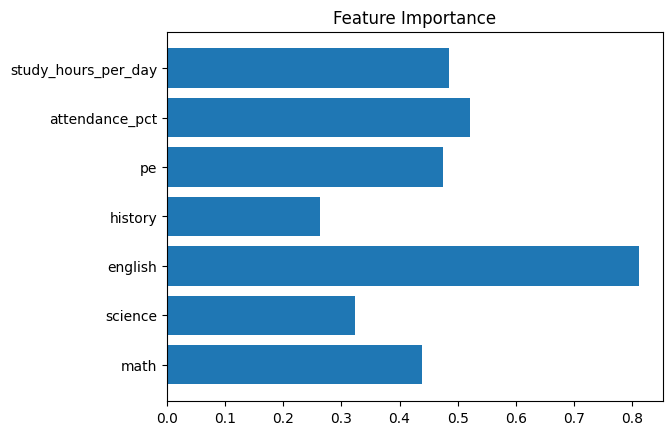


New Student Prediction: Pass
Probability: [[0.09203526 0.90796474]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [1]:
# ==============================
# IMPORTS
# ==============================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# ==============================
# LOAD DATA (NO CSV NEEDED)
# ==============================
data = """name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
Alice,88,92,76,80,95,92,4.5,1
Bob,42,55,48,50,60,65,1.2,0
Charlie,75,70,80,68,88,85,3.0,1
Diana,95,98,91,89,97,98,6.0,1
Eve,38,42,50,45,55,58,0.8,0
Frank,60,65,72,58,70,78,2.5,1
Grace,55,48,44,52,62,60,1.5,0
Henry,82,79,85,77,90,88,4.0,1
Iris,70,74,68,65,78,80,3.5,1
Jack,30,35,40,28,45,50,0.5,0
Karen,65,60,70,62,75,72,2.8,1
Liam,48,52,44,55,58,62,1.8,0
Mia,91,94,88,92,96,95,5.5,1
Noah,58,62,55,60,68,70,2.0,0
Olivia,78,75,82,70,85,84,3.8,1
"""

df = pd.read_csv(StringIO(data))

# ==============================
# TASK 1: DATA EXPLORATION
# ==============================
print("First 5 rows:\n", df.head())
print("\nShape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nSummary:\n", df.describe())

print("\nPass/Fail Count:\n", df["passed"].value_counts())

subject_cols = ['math', 'science', 'english', 'history', 'pe']
df["avg_score"] = df[subject_cols].mean(axis=1)

print("\nAverage score (Pass):")
print(df[df["passed"] == 1][subject_cols].mean())

print("\nAverage score (Fail):")
print(df[df["passed"] == 0][subject_cols].mean())

top_student = df.loc[df["avg_score"].idxmax()]
print("\nTop Student:", top_student["name"])

# ==============================
# TASK 2: MATPLOTLIB
# ==============================

# 1 Bar chart
df[subject_cols].mean().plot(kind='bar', title="Average Score per Subject")
plt.savefig("plot1_bar.png")
plt.show()

# 2 Histogram
plt.hist(df["math"], bins=5)
plt.title("Math Score Distribution")
plt.savefig("plot2_hist.png")
plt.show()

# 3 Scatter
pass_df = df[df["passed"] == 1]
fail_df = df[df["passed"] == 0]

plt.scatter(pass_df["study_hours_per_day"], pass_df["avg_score"], label="Pass")
plt.scatter(fail_df["study_hours_per_day"], fail_df["avg_score"], label="Fail")
plt.legend()
plt.title("Study Hours vs Avg Score")
plt.savefig("plot3_scatter.png")
plt.show()

# 4 Box plot
plt.boxplot([pass_df["attendance_pct"], fail_df["attendance_pct"]], labels=["Pass", "Fail"])
plt.title("Attendance Comparison")
plt.savefig("plot4_box.png")
plt.show()

# 5 Line plot
plt.plot(df["name"], df["math"], marker='o', label="Math")
plt.plot(df["name"], df["science"], marker='o', label="Science")
plt.xticks(rotation=45)
plt.legend()
plt.title("Scores per Student")
plt.savefig("plot5_line.png")
plt.show()

# ==============================
# TASK 3: SEABORN
# ==============================

# Bar plot
plt.figure()
sns.barplot(data=df, x="passed", y="math")
plt.savefig("plot6_seaborn_bar.png")
plt.show()

# Scatter + regression
sns.regplot(data=pass_df, x="attendance_pct", y="avg_score", label="Pass")
sns.regplot(data=fail_df, x="attendance_pct", y="avg_score", label="Fail")
plt.legend()
plt.savefig("plot7_seaborn_scatter.png")
plt.show()

# ==============================
# TASK 4: MACHINE LEARNING
# ==============================

X = df[['math','science','english','history','pe','attendance_pct','study_hours_per_day']]
y = df['passed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Accuracy
train_acc = model.score(X_train_scaled, y_train)
test_pred = model.predict(X_test_scaled)
test_acc = accuracy_score(y_test, test_pred)

print("\nTraining Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

# Predictions
names = df.loc[X_test.index, "name"]
for i in range(len(names)):
    print(names.iloc[i], "| Actual:", y_test.iloc[i], "| Pred:", test_pred[i])

# Feature Importance
coeff = model.coef_[0]
features = X.columns

plt.barh(features, coeff)
plt.title("Feature Importance")
plt.show()

# Bonus Prediction
new_student = [[75,70,68,65,80,82,3.2]]
new_scaled = scaler.transform(new_student)
pred = model.predict(new_scaled)
prob = model.predict_proba(new_scaled)

print("\nNew Student Prediction:", "Pass" if pred[0]==1 else "Fail")
print("Probability:", prob)